

---

# ▶  **Hotel Booking Dataset — Executive EDA**


---



◼ **End-to-end Exploratory Data Analysis and Management Report**

This notebook covers dataset understanding, data-quality assessment, cleaning, preprocessing, descriptive statistics, univariate/bivariate analysis, group-wise analysis, correlation analysis, visualization, business insights, and management recommendations.

◼ **Important:** `Estimated_Revenue` is treated as an estimated booking-value metric, not automatically as realized revenue.


---



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

file_path = "Day15_Executive_Hotel_Booking_EDA_Dataset (1).csv"
raw = pd.read_csv(file_path)
print("Dataset shape:", raw.shape)
display(raw.head())


Dataset shape: (25180, 35)


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50




---
## 1. Dataset Understanding


---



In [3]:
display(raw.info())
display(raw.describe(include="all").T)
print("Duplicate rows:", raw.duplicated().sum())
print("Duplicate Booking_ID values:", raw.Booking_ID.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  object 
 1   Hotel_Type                   25180 non-null  object 
 2   Hotel_Location               25074 non-null  object 
 3   Booking_Date                 25180 non-null  object 
 4   Arrival_Date                 25180 non-null  object 
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  object 
 12  Market_Segment               25180 non-null  object 
 13  Distribution_Cha

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Booking_ID,25180,25000,HTL014830,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hotel_Type,25180,5,City Hotel,15606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hotel_Location,25074,11,Dubai,3171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking_Date,25180,731,2025-12-10,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Arrival_Date,25180,1073,2026-01-02,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lead_Time_Days,25180.0,NaN,NaN,NaN,182.200556,105.604452,0.0,91.0,182.0,273.0,920.0
Weekend_Nights,25180.0,NaN,NaN,NaN,1.240429,1.063802,0.0,0.0,1.0,2.0,3.0
Weekday_Nights,25180.0,NaN,NaN,NaN,2.451072,2.031003,0.0,1.0,2.0,4.0,13.0
Adults,25180.0,NaN,NaN,NaN,2.198967,0.662379,1.0,2.0,2.0,2.0,7.0
Children,25059.0,NaN,NaN,NaN,0.372122,0.657811,0.0,0.0,0.0,1.0,6.0


Duplicate rows: 180
Duplicate Booking_ID values: 180




---


## 2. Data Quality Assessment


---



In [4]:
missing = raw.isna().sum().sort_values(ascending=False)
missing_report = pd.DataFrame({"Missing_Count":missing, "Missing_%":(missing/len(raw)*100).round(2)})
display(missing_report[missing_report.Missing_Count>0])

for c in ["Hotel_Type","Market_Segment","Meal_Type"]:
    print("\n", c)
    display(raw[c].value_counts(dropna=False))


,Missing_Count,Missing_%
Company_ID,20729,82.32
Country,466,1.85
Agent_ID,304,1.21
Meal_Type,245,0.97
Satisfaction_Score,164,0.65
Children,121,0.48
Hotel_Location,106,0.42
ADR,82,0.33



 Hotel_Type


,count
Hotel_Type,
City Hotel,15606
Resort Hotel,9454
CITY HOTEL,44
city hotel,43
City hotel,33



 Market_Segment


,count
Market_Segment,
Online TA,10782
Offline TA/TO,5483
Direct,3827
Corporate,3012
Groups,1924
ONLINE TA,53
online ta,51
Online TA,48



 Meal_Type


,count
Meal_Type,
BB,5027
Undefined,4978
SC,4945
HB,4939
FB,4939
NaN,245
BB,38
bb,32
B&B,30




---

# ◼ ### Data-quality decisions
- Remove exact duplicate rows.
- Standardize category case and whitespace.
- Treat missing Company_ID and Agent_ID as identifier categories (`No Company`, `No Agent`).
- Impute missing Children with 0, ADR with the median, and Satisfaction_Score with the median.
- Convert date fields to datetime.
- Flag arrival dates earlier than booking dates for review.
- Cap the apparent out-of-range satisfaction value at 5.
- Report IQR outliers as diagnostic flags rather than deleting potentially valid operational observations.


---



In [5]:
df = raw.drop_duplicates().copy()

cat_cols = ["Hotel_Type","Market_Segment","Meal_Type","Deposit_Type","Customer_Type",
            "Reservation_Status","Hotel_Location","Distribution_Channel",
            "Room_Type_Reserved","Room_Type_Assigned"]
for c in cat_cols:
    df[c] = df[c].astype("string").str.strip()

df["Hotel_Type"] = df["Hotel_Type"].str.title()
df["Market_Segment"] = df["Market_Segment"].str.title()
df["Meal_Type"] = df["Meal_Type"].str.upper().replace({"B&B":"BB"})

for c in ["Hotel_Location","Country","Meal_Type"]:
    df[c] = df[c].fillna("Unknown")
df["Agent_ID"] = df["Agent_ID"].fillna(0).astype(int).astype(str).replace("0","No Agent")
df["Company_ID"] = df["Company_ID"].fillna(0).astype(int).astype(str).replace("0","No Company")
df["Children"] = df["Children"].fillna(0)
df["ADR"] = df["ADR"].fillna(df["ADR"].median())
df["Satisfaction_Score"] = df["Satisfaction_Score"].fillna(df["Satisfaction_Score"].median()).clip(0,5)

for c in ["Booking_Date","Arrival_Date","Reservation_Status_Date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")
df["Date_Quality_Flag"] = np.where(df.Arrival_Date < df.Booking_Date, "Check", "OK")
print("Cleaned shape:", df.shape)


Cleaned shape: (25000, 36)




---

## 3. Feature Engineering

---



In [6]:
df["Booking_Year"] = df.Booking_Date.dt.year
df["Booking_Month"] = df.Booking_Date.dt.month
df["Booking_Month_Name"] = df.Booking_Date.dt.strftime("%b")
df["Arrival_Year"] = df.Arrival_Date.dt.year
df["Arrival_Month"] = df.Arrival_Date.dt.month
df["Arrival_Weekday"] = df.Arrival_Date.dt.day_name()
df["Party_Size"] = df.Adults + df.Children + df.Babies
df["Revenue_per_Night"] = df.Estimated_Revenue / df.Total_Nights
df["Lead_Band"] = pd.cut(df.Lead_Time_Days,[-1,30,90,180,365,np.inf],labels=["0–30","31–90","91–180","181–365","366+"])
df["Stay_Type"] = pd.cut(df.Total_Nights,[0,2,5,np.inf],labels=["Short (1–2)","Medium (3–5)","Long (6+)"])
display(df[["Lead_Time_Days","Lead_Band","Total_Nights","Stay_Type","Party_Size","Revenue_per_Night"]].head())


,Lead_Time_Days,Lead_Band,Total_Nights,Stay_Type,Party_Size,Revenue_per_Night
0,340,181–365,4,Medium (3–5),2.0,178.662500
1,256,181–365,3,Medium (3–5),4.0,125.810000
2,41,31–90,2,Short (1–2),4.0,148.030000
3,23,0–30,2,Short (1–2),2.0,166.815000
4,282,181–365,3,Medium (3–5),4.0,76.833333




---
## 4. Descriptive Statistics


---



In [7]:
display(df.describe().T)
print("Cancellation rate:", round(df.Is_Canceled.mean()*100,2), "%")
print("Total estimated revenue:", round(df.Estimated_Revenue.sum(),2))
print("Average estimated revenue per booking:", round(df.Estimated_Revenue.mean(),2))
print("Median ADR:", round(df.ADR.median(),2))


,count,mean,min,25%,50%,75%,max,std
Booking_Date,25000,2025-01-01 02:16:03.072000,2024-01-01 00:00:00,2024-07-01 00:00:00,2024-12-30 12:00:00,2025-07-05 00:00:00,2025-12-31 00:00:00,NaN
Arrival_Date,25000,2025-07-02 05:55:37.344000,2024-01-02 00:00:00,2024-12-30 00:00:00,2025-07-02 00:00:00,2026-01-03 00:00:00,2026-12-29 00:00:00,NaN
Lead_Time_Days,25000.0,182.2174,0.0,91.0,182.0,273.0,920.0,105.632493
Weekend_Nights,25000.0,1.24088,0.0,0.0,1.0,2.0,3.0,1.064003
Weekday_Nights,25000.0,2.45,0.0,1.0,2.0,4.0,13.0,2.03007
Adults,25000.0,2.19848,1.0,2.0,2.0,2.0,7.0,0.662226
Children,25000.0,0.37068,0.0,0.0,0.0,1.0,6.0,0.65679
Babies,25000.0,0.04312,0.0,0.0,0.0,0.0,2.0,0.22535
Is_Repeated_Guest,25000.0,0.17288,0.0,0.0,0.0,0.0,1.0,0.378151
Previous_Cancellations,25000.0,0.03856,0.0,0.0,0.0,0.0,3.0,0.250989


Cancellation rate: 72.18 %
Total estimated revenue: 13384199.45
Average estimated revenue per booking: 535.37
Median ADR: 134.41




---

## 5. Univariate Analysis

---



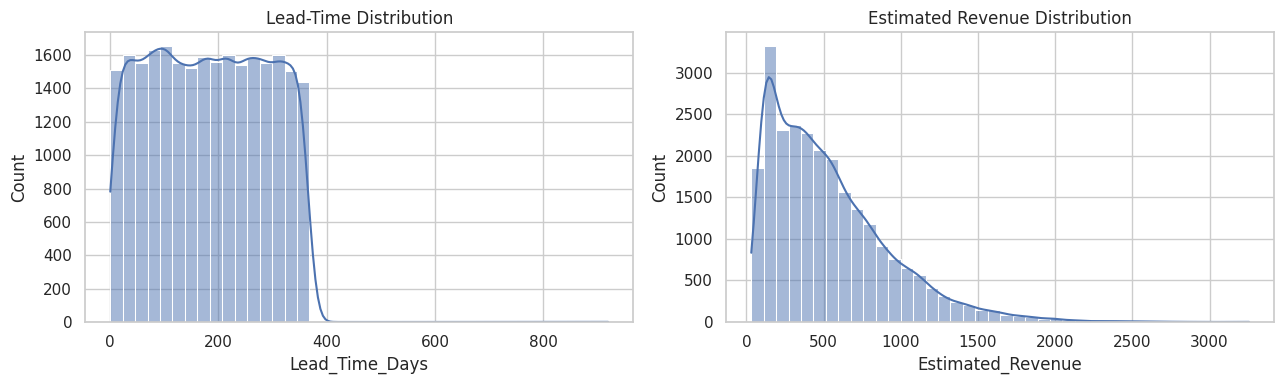

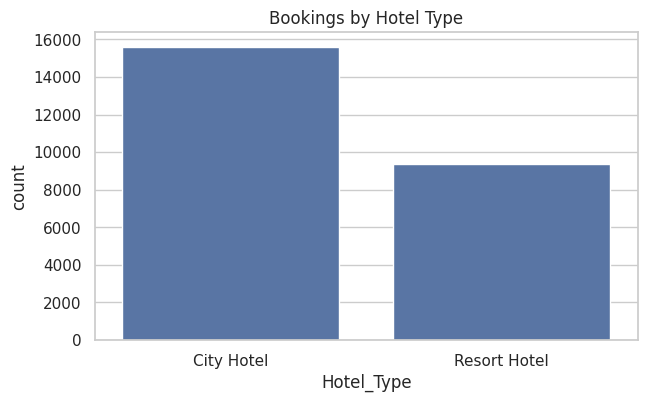

In [8]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
sns.histplot(df.Lead_Time_Days,bins=40,kde=True,ax=axes[0])
axes[0].set_title("Lead-Time Distribution")
sns.histplot(df.Estimated_Revenue,bins=40,kde=True,ax=axes[1])
axes[1].set_title("Estimated Revenue Distribution")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
sns.countplot(data=df,x="Hotel_Type")
plt.title("Bookings by Hotel Type")
plt.show()




---

## 6. Bivariate and Group-wise Analysis

---



In [9]:
hotel_summary = df.groupby("Hotel_Type").agg(
    Bookings=("Booking_ID","count"), Cancellation_Rate=("Is_Canceled","mean"),
    Estimated_Revenue=("Estimated_Revenue","sum"), Avg_ADR=("ADR","mean"),
    Avg_Nights=("Total_Nights","mean")).sort_values("Estimated_Revenue",ascending=False)
display(hotel_summary)

segment_summary = df.groupby("Market_Segment").agg(
    Bookings=("Booking_ID","count"), Cancellation_Rate=("Is_Canceled","mean"),
    Estimated_Revenue=("Estimated_Revenue","sum"), Avg_ADR=("ADR","mean")).sort_values("Estimated_Revenue",ascending=False)
display(segment_summary)

deposit_summary = df.groupby("Deposit_Type").agg(
    Bookings=("Booking_ID","count"), Cancellation_Rate=("Is_Canceled","mean")).sort_values("Cancellation_Rate",ascending=False)
display(deposit_summary)


,Bookings,Cancellation_Rate,Estimated_Revenue,Avg_ADR,Avg_Nights
Hotel_Type,,,,,
Resort Hotel,9389,0.703057,7365874.95,173.556962,4.518053
City Hotel,15611,0.733009,6018324.50,120.759541,3.195952


,Bookings,Cancellation_Rate,Estimated_Revenue,Avg_ADR
Market_Segment,,,,
Online Ta,10852,0.751014,5932008.25,143.209292
Offline Ta/To,5440,0.704228,2944293.73,142.393578
Direct,3808,0.712185,2098049.99,143.249165
Corporate,2990,0.674916,1492611.61,134.156130
Groups,1910,0.697906,917235.87,125.317050


,Bookings,Cancellation_Rate
Deposit_Type,,
Non Refund,12401,0.929764
Refundable,455,0.547253
No Deposit,12144,0.515893


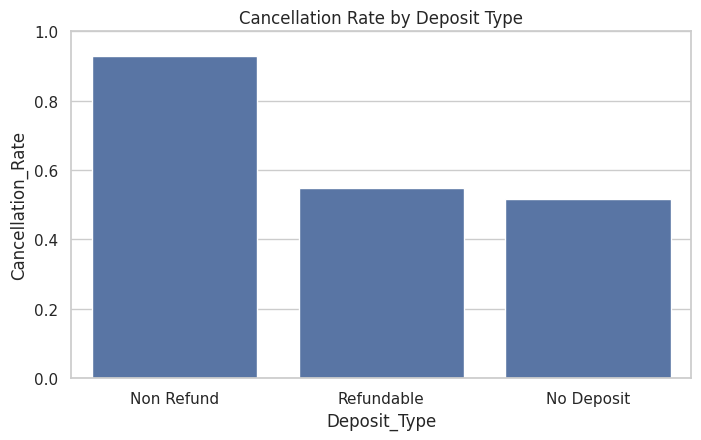

,Bookings,Cancellation_Rate
Lead_Band,,
0–30,2105,0.451306
31–90,4122,0.523775
91–180,6171,0.668935
181–365,12600,0.857619
366+,2,0.500000


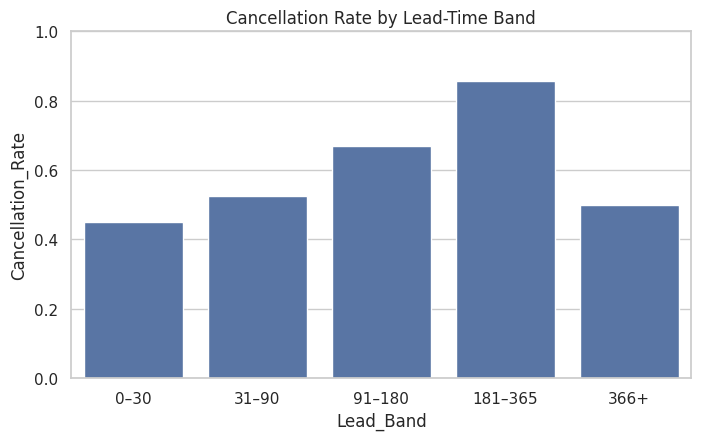

In [10]:
plt.figure(figsize=(8,4.5))
sns.barplot(data=deposit_summary.reset_index(),x="Deposit_Type",y="Cancellation_Rate")
plt.title("Cancellation Rate by Deposit Type"); plt.ylim(0,1); plt.show()

lead_summary = df.groupby("Lead_Band",observed=True).agg(
    Bookings=("Booking_ID","count"),Cancellation_Rate=("Is_Canceled","mean"))
display(lead_summary)

plt.figure(figsize=(8,4.5))
sns.barplot(data=lead_summary.reset_index(),x="Lead_Band",y="Cancellation_Rate")
plt.title("Cancellation Rate by Lead-Time Band"); plt.ylim(0,1); plt.show()




---
## 7. Revenue, Destination and Pricing Analysis


---



,Bookings,Cancellation_Rate,Estimated_Revenue,Avg_ADR
Hotel_Location,,,,
Goa,1957,0.680123,1568006.15,174.230613
Bali,1882,0.706695,1494345.71,173.716445
Algarve,1902,0.711356,1471887.02,174.380691
Maldives,1845,0.714905,1435469.77,172.877043
Phuket,1813,0.702703,1403754.61,172.348919
Dubai,3148,0.735705,1216911.07,121.068766
London,3106,0.739858,1207466.30,121.533435
Lisbon,3148,0.731576,1198314.63,120.623391
Barcelona,3061,0.734401,1175082.43,120.343401


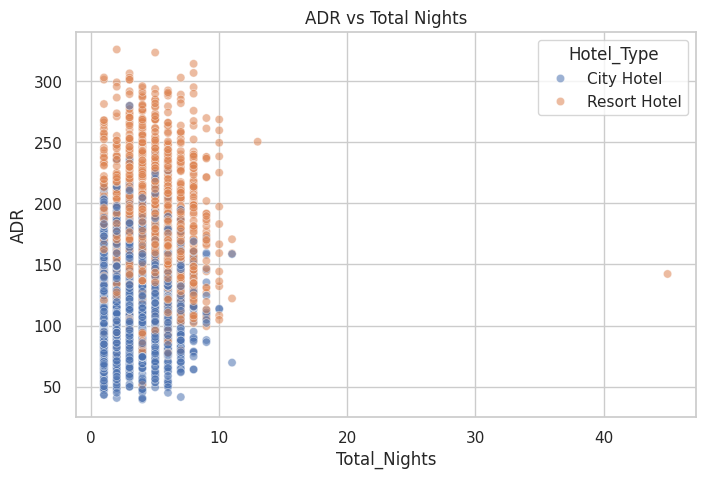

In [11]:
location_summary = df.groupby("Hotel_Location").agg(
    Bookings=("Booking_ID","count"),Cancellation_Rate=("Is_Canceled","mean"),
    Estimated_Revenue=("Estimated_Revenue","sum"),Avg_ADR=("ADR","mean")
).sort_values("Estimated_Revenue",ascending=False)
display(location_summary.head(10))

sample=df.sample(min(5000,len(df)),random_state=42)
plt.figure(figsize=(8,5))
sns.scatterplot(data=sample,x="Total_Nights",y="ADR",hue="Hotel_Type",alpha=.55)
plt.title("ADR vs Total Nights"); plt.show()




---


## 8. Correlation Analysis
---



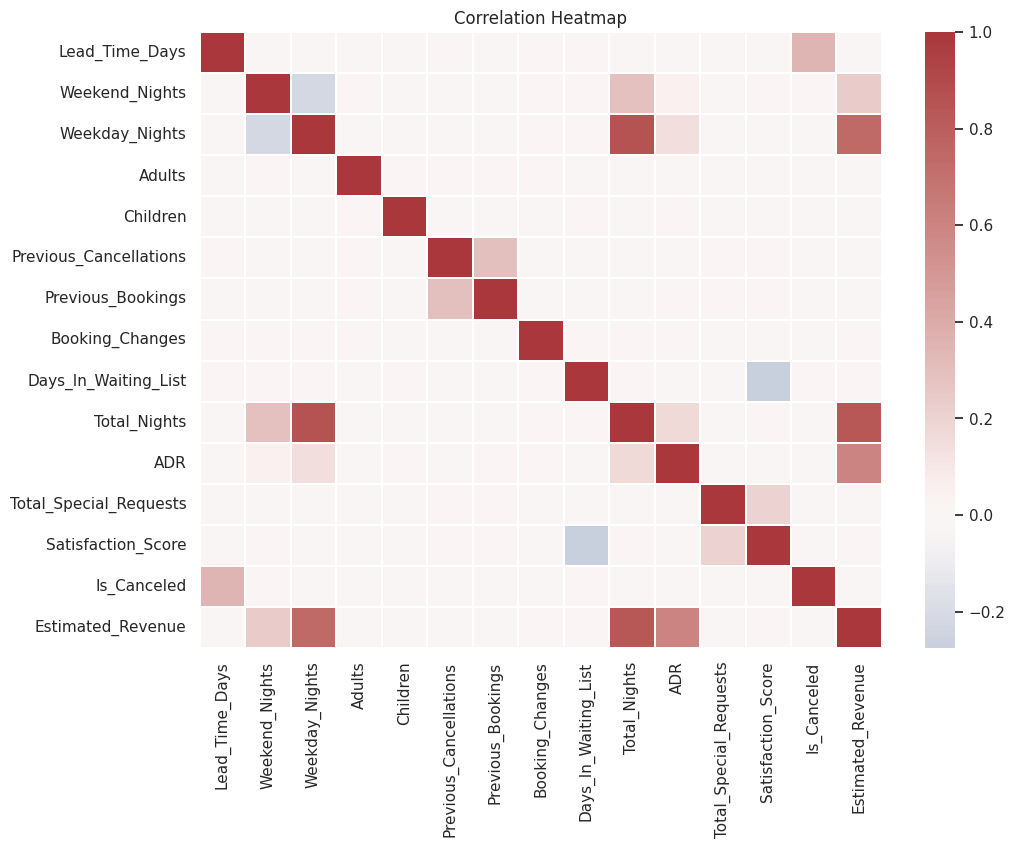

,Correlation
Estimated_Revenue,1.000000
Total_Nights,0.837965
Weekday_Nights,0.736105
ADR,0.602987
Weekend_Nights,0.237120
Booking_Changes,0.013054
Days_In_Waiting_List,0.010958
Satisfaction_Score,0.004743
Children,-0.000125
Adults,-0.000634


In [12]:
corr_cols = ["Lead_Time_Days","Weekend_Nights","Weekday_Nights","Adults","Children",
"Previous_Cancellations","Previous_Bookings","Booking_Changes","Days_In_Waiting_List",
"Total_Nights","ADR","Total_Special_Requests","Satisfaction_Score","Is_Canceled","Estimated_Revenue"]
corr=df[corr_cols].corr()
plt.figure(figsize=(11,8))
sns.heatmap(corr,cmap="vlag",center=0,linewidths=.3)
plt.title("Correlation Heatmap"); plt.show()
display(corr.Estimated_Revenue.sort_values(ascending=False).to_frame("Correlation"))




---
## 9. Outlier Detection — IQR


---



In [13]:
outlier_report=[]
numeric_cols=["Lead_Time_Days","Weekend_Nights","Weekday_Nights","Adults","Children","Babies",
"Previous_Cancellations","Previous_Bookings","Booking_Changes","Days_In_Waiting_List","Total_Nights",
"ADR","Required_Car_Parking_Spaces","Total_Special_Requests","Satisfaction_Score","Estimated_Revenue"]
for c in numeric_cols:
    q1,q3=df[c].quantile([.25,.75]); iqr=q3-q1
    lower,upper=q1-1.5*iqr,q3+1.5*iqr
    outlier_report.append([c,q1,q3,lower,upper,int(((df[c]<lower)|(df[c]>upper)).sum())])
outlier_report=pd.DataFrame(outlier_report,columns=["Variable","Q1","Q3","Lower_Bound","Upper_Bound","IQR_Outliers"]).sort_values("IQR_Outliers",ascending=False)
display(outlier_report)


,Variable,Q1,Q3,Lower_Bound,Upper_Bound,IQR_Outliers
3,Adults,2.0000,2.000,2.00000,2.00000,7529
12,Required_Car_Parking_Spaces,0.0000,0.000,0.00000,0.00000,4543
7,Previous_Bookings,0.0000,0.000,0.00000,0.00000,4322
9,Days_In_Waiting_List,0.0000,1.000,-1.50000,2.50000,4082
8,Booking_Changes,0.0000,1.000,-1.50000,2.50000,1279
5,Babies,0.0000,0.000,0.00000,0.00000,959
6,Previous_Cancellations,0.0000,0.000,0.00000,0.00000,687
15,Estimated_Revenue,230.6200,737.570,-529.80500,1497.99500,652
11,ADR,105.6975,168.955,10.81125,263.84125,360
14,Satisfaction_Score,3.6000,4.130,2.80500,4.92500,282




---
## 10. Key Business Insights

1. **Cancellation risk is the dominant commercial issue:** approximately 72% of cleaned bookings are canceled.
2. **Deposit policy matters:** non-refundable bookings have roughly 93% cancellation, materially higher than no-deposit bookings.
3. **Long lead times increase risk:** 181–365 day bookings have about 86% cancellation versus about 45% for 0–30 day bookings.
4. **Resorts generate stronger booking value:** Resort Hotel has higher ADR and longer stays, producing the highest total estimated revenue.
5. **Online TA is a major value channel but needs tighter controls:** it leads market-segment estimated revenue while also carrying above-average cancellation risk.



---





---


## 11. Management Recommendations

1. Build a cancellation-risk score using lead time, deposit type, channel, property type, and customer history.
2. Use staged deposits or commitment incentives for high-risk long-lead reservations.
3. Review Online TA cancellation terms, payment guarantees, commissions, and inventory allocation.
4. Protect resort inventory and optimize pricing where ADR and stay length support higher value.
5. Monitor destination-level revenue, ADR, and cancellation rate together rather than relying on booking volume.
6. Develop extended-stay packages and upsells because total nights has a strong positive association with estimated revenue.
7. Enforce source-system validation for unique booking IDs, standardized categories, valid date logic, and bounded satisfaction scores.

---





---
## 12. Conclusion
The analysis identifies cancellation reduction, channel policy, lead-time management, resort pricing, and destination optimization as the most actionable business priorities. The cleaned dataset can also support future cancellation prediction and revenue-optimization models.


---

